In [168]:
# importing libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [169]:
# loading data

df = pd.read_csv("../data/raw_data.csv")

#### Data Wrangling

In [170]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [171]:
# shape 

df.shape

(119390, 32)

In [172]:
# features / columns

df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [173]:
# baisc info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [174]:
# convert to datetime dtype 

df['reservation_date'] = pd.to_datetime(df['reservation_status_date'],format = "%d/%m/%Y")

In [175]:
# recheck dtype

print(df['reservation_date'].dtype)

datetime64[us]


In [176]:
# dropping original column

df = df.drop(columns = 'reservation_status_date')

In [177]:
# segregate numricals 

num_cols = df.select_dtypes(include='number').columns

cat_cols = df.select_dtypes(include='object').columns

In [178]:
# summary stats for categorical columns

df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [179]:
# ascertain unique values

for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("__"*50)

hotel
<StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
____________________________________________________________________________________________________
arrival_date_month
<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str
____________________________________________________________________________________________________
meal
<StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
____________________________________________________________________________________________________
country
<StringArray>
['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA',   nan, 'ROU', 'NOR', 'OMN',
 ...
 'ATA', 'GTM', 'ASM', 'MRT', 'NCL', 'KIR', 'SDN', 'ATF', 'SLE', 'LAO']
Length: 178, dtype: str
____________________________________________________________________________________________________
market_segment
<StringArray>
[       

In [180]:
# check for missing values

df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [181]:
# dropping columns 'agent' & 'company'

df = df.drop(columns=['agent' , 'company'])

In [182]:
# update numricals 

num_cols = df.select_dtypes(include='number').columns

In [183]:
# handle missing values

df.dropna(inplace = True)

In [184]:
# recheck for missing values

df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [185]:
# summary stats for numericals

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


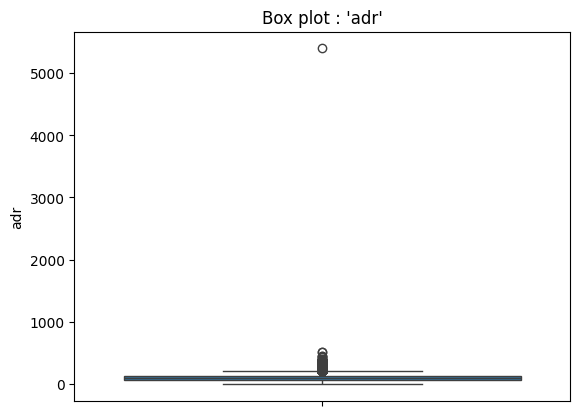

In [186]:
# plot box for outlier detection

plt.title("Box plot : 'adr'")
sns.boxplot(df['adr'])
plt.show()

In [187]:
# set lower & upper bound

Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - (IQR * 1.5)
upper = Q3 + (IQR * 1.5)
print(f"lower : {lower}, upper : {upper}")

lower : -14.0, upper : 210.0


In [188]:
# handle outliers

df['adr'] = df['adr'].clip(lower,upper)

In [189]:
df['adr'].describe()

count    118898.000000
mean        100.794043
std          44.532606
min          -6.380000
25%          70.000000
50%          95.000000
75%         126.000000
max         210.000000
Name: adr, dtype: float64


### EDA & data visualization


In [190]:
# distribution count

df['is_canceled'].value_counts(normalize=True) * 100

is_canceled
0    62.864808
1    37.135192
Name: proportion, dtype: float64

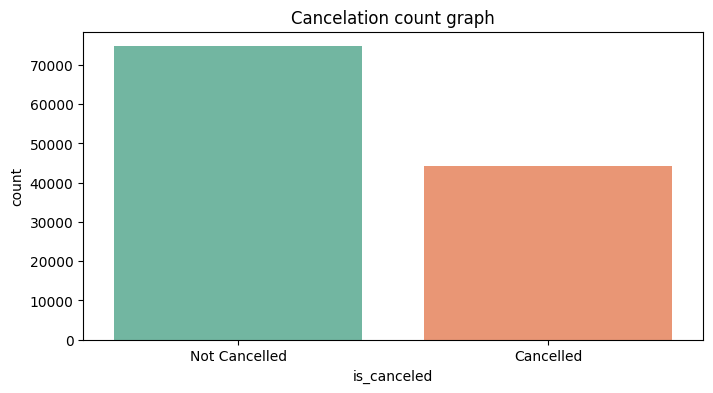

In [191]:
# cancelation count plot

plt.figure(figsize= (8,4))
sns.countplot(x=df['is_canceled'].map({0:'Not Cancelled',1:'Cancelled'}),palette="Set2")
plt.title("Cancelation count graph")
plt.show()

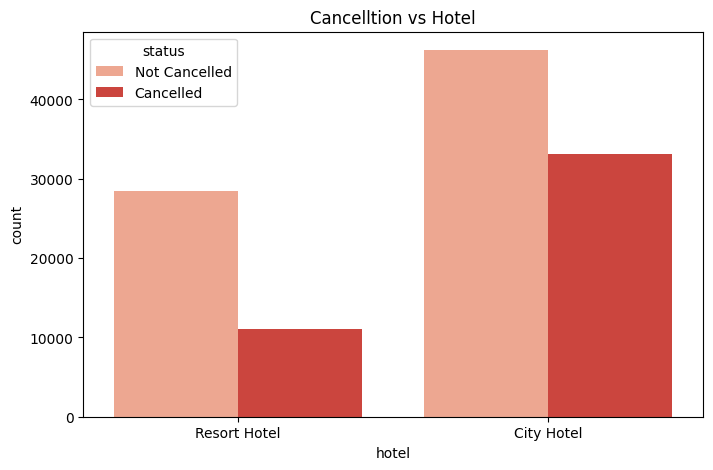

In [192]:
# cancelation based on hotel

plt.figure(figsize=(8,5))
plt.title("Cancelltion vs Hotel")
y = df['is_canceled'].map({0:"Not Cancelled",1:"Cancelled"})
sns.countplot(x=df['hotel'],hue=y,palette='Reds')
plt.legend(title="status",loc="upper left")
plt.show()

In [193]:
# Cancellation percentages per hotel type

df.groupby('hotel')['is_canceled'].value_counts(normalize=True).mul(100).round(2)

hotel         is_canceled
City Hotel    0              58.29
              1              41.71
Resort Hotel  0              72.02
              1              27.98
Name: proportion, dtype: float64

In [194]:
# reservations per month

df['month'] = df['reservation_date'].dt.month

month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

df['month_name'] = df['month'].map(month_map)

In [195]:
df['month_name'].value_counts()

month_name
Jul    12074
Aug    11223
Oct    11095
Jan    10622
May    10294
Mar    10177
Apr     9957
Feb     9436
Sep     9359
Jun     9255
Nov     8052
Dec     7354
Name: count, dtype: int64

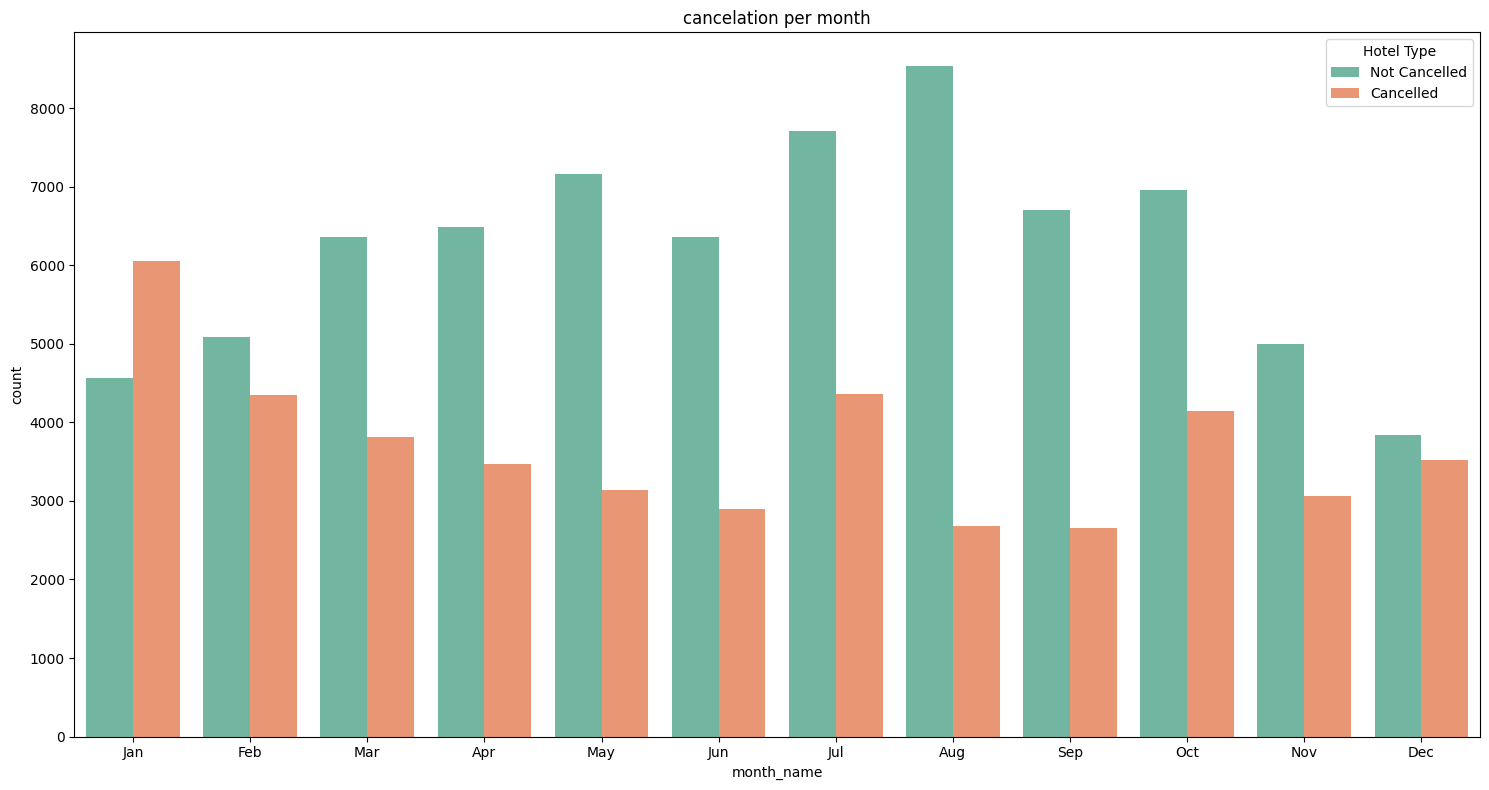

In [196]:
# cancelation per month per hotel

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(15,8))
plt.title("cancelation per month")
sns.countplot(
    data=df, 
    x='month_name', 
    hue=y,
    order = month_order,
    palette='Set2'
)
plt.legend(title="Hotel Type")
plt.tight_layout()
plt.show()

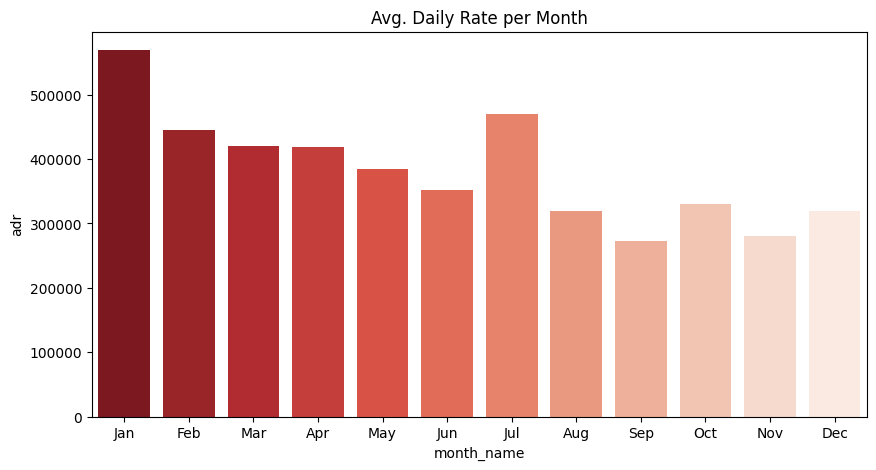

In [197]:
# ADR per month

plt.figure(figsize=(10,5))
plt.title("ADR per month")
data = df[df['is_canceled']==1].groupby('month_name')[['adr']].sum()
sns.barplot(x='month_name',y='adr',data=data,order = month_order,palette='Reds_r')
plt.title("Avg. Daily Rate per Month")
plt.show()

In [198]:
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

In [199]:
data.sort_values(by='adr',ascending = False)

,adr
month_name,
Jan,569538.66
Jul,470440.57
Feb,445786.98
Mar,420363.92
Apr,418249.06
May,383965.46
Jun,351306.61
Oct,330024.95
Aug,318804.30


In [200]:
# top 10 countries with highest cancelation

cancelled = df[df['is_canceled']==1]

top_10 = cancelled['country'].value_counts()[:10]

top_10

country
PRT    27515
GBR     2453
ESP     2177
FRA     1934
ITA     1333
DEU     1218
IRL      832
BRA      830
USA      501
BEL      474
Name: count, dtype: int64

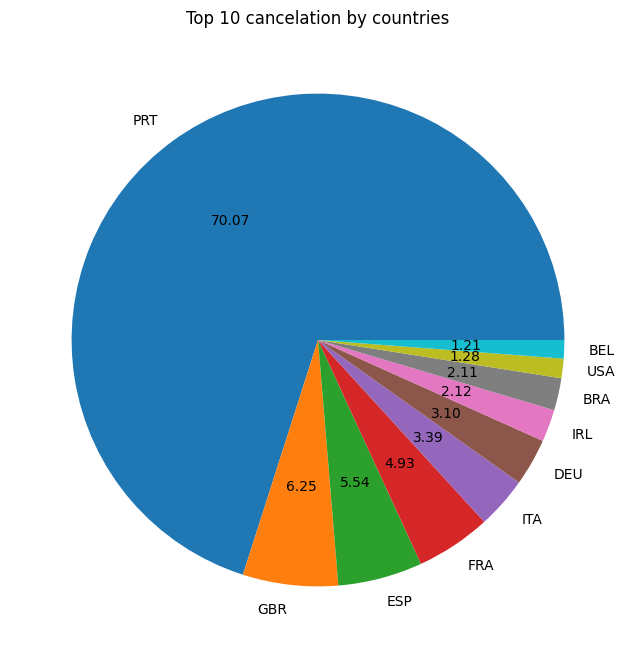

In [201]:
# top 10 cancellation countries pie chart
%matplotlib inline
plt.figure(figsize=(8,8))
plt.title("Top 10 cancelation by countries")
plt.pie(top_10,autopct="%.2f",labels=top_10.index)
plt.show()

In [202]:
# booking source segementaion

df['market_segment'].value_counts(normalize = True).mul(100).round(2)

market_segment
Online TA        47.44
Offline TA/TO    20.32
Groups           16.66
Direct           10.47
Corporate         4.30
Complementary     0.62
Aviation          0.20
Name: proportion, dtype: float64

In [203]:
# cancelation based on market_segment

cancelled['market_segment'].value_counts(normalize = True).mul(100).round(2)

market_segment
Online TA        46.97
Groups           27.40
Offline TA/TO    18.75
Direct            4.35
Corporate         2.22
Complementary     0.20
Aviation          0.12
Name: proportion, dtype: float64

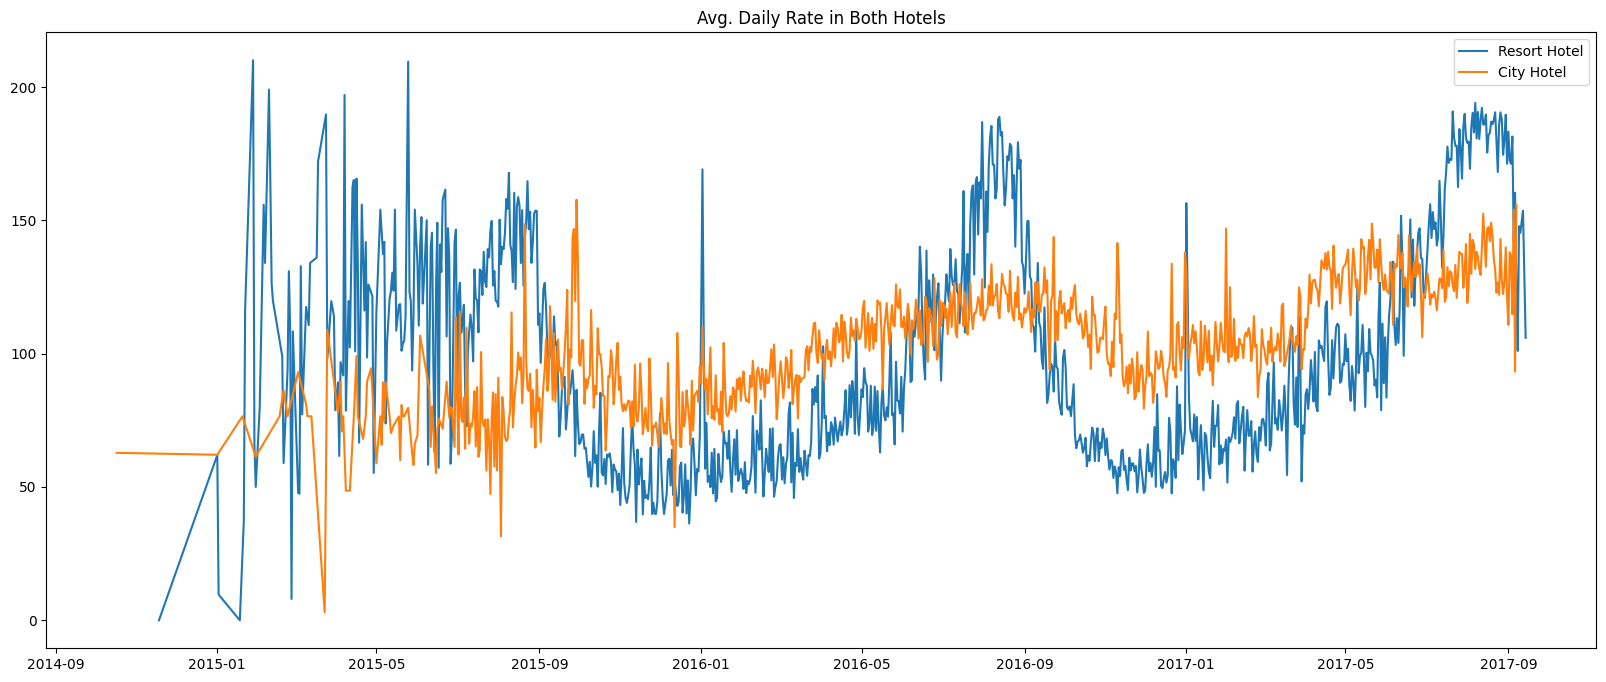

In [204]:
# hotels vs adr (avg daily rate)

resort_hotel = df[df['hotel']=="Resort Hotel"]
city_hotel = df[df['hotel']=="City Hotel"]

resort_hotel = resort_hotel.groupby('reservation_date')[['adr']].mean()
city_hotel = city_hotel.groupby('reservation_date')[['adr']].mean()

plt.figure(figsize=(20,8))
plt.title("Avg. Daily Rate in Both Hotels")
plt.plot(resort_hotel.index,resort_hotel['adr'],label="Resort Hotel")
plt.plot(city_hotel.index,city_hotel['adr'],label="City Hotel")
plt.legend()
plt.show()

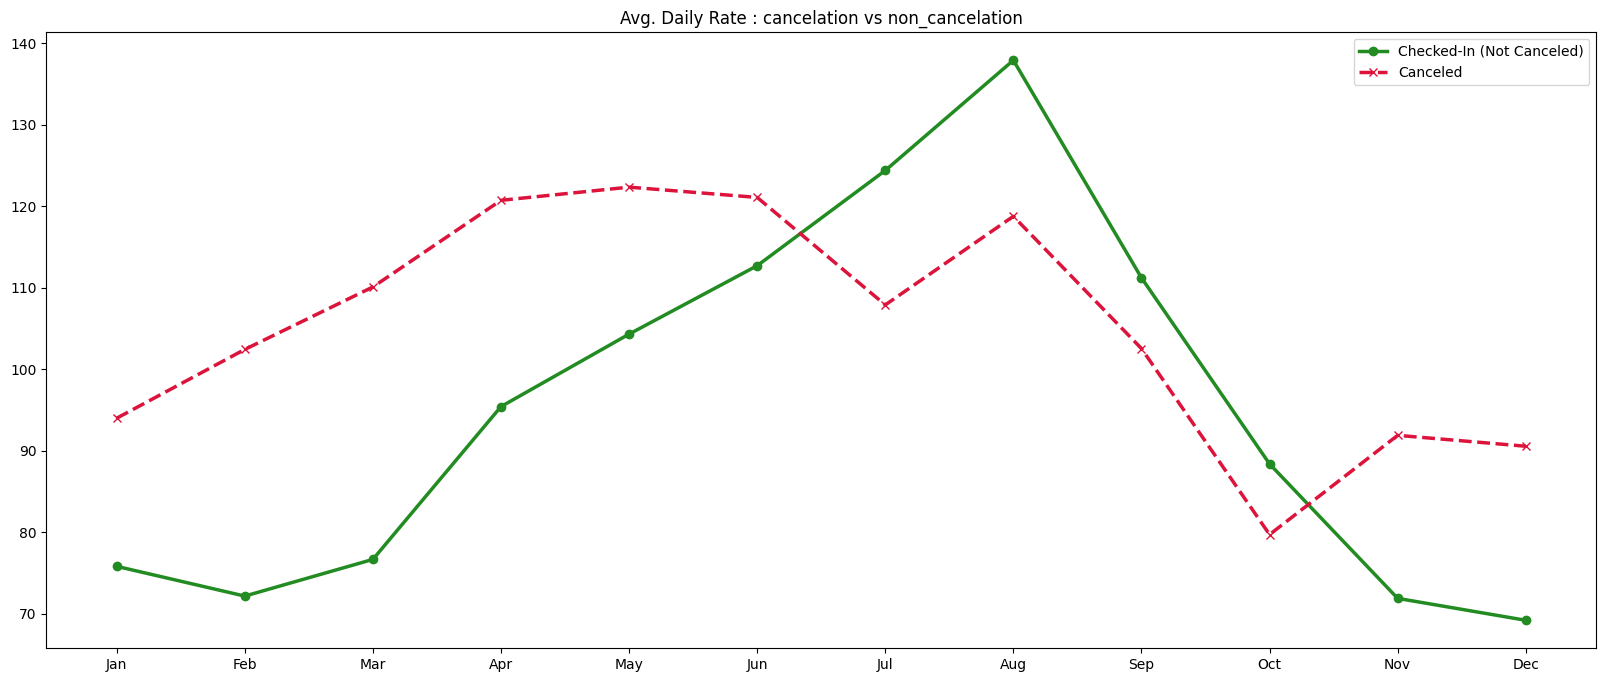

In [205]:
# adr vs cancelation

canceled = df[df['is_canceled']==1]
not_canceled = df[df['is_canceled']==0]

adr_canceled_monthly = canceled.groupby('month_name')['adr'].mean().reindex(month_order)
adr_not_canceled_monthly = not_canceled.groupby('month_name')['adr'].mean().reindex(month_order)

plt.figure(figsize=(20,8))
plt.title("Avg. Daily Rate : cancelation vs non_cancelation")

plt.plot(adr_not_canceled_monthly.index, adr_not_canceled_monthly.values, 
         label="Checked-In (Not Canceled)", marker='o', color='forestgreen', linewidth=2.5)


plt.plot(adr_canceled_monthly.index, adr_canceled_monthly.values, 
         label="Canceled", marker='x', color='crimson', linewidth=2.5, linestyle='--')
plt.legend()
plt.show()

In [207]:
# save processed dataset

path = "../data/processed.csv"

df.to_csv(path,index=False)

print(f"Processed dataset saved successfully at {path}")

Processed dataset saved successfully at ../data/processed.csv
